<a href="https://colab.research.google.com/github/CPTR295/Sample-LLMs/blob/main/Inference_Time_Scaling_Via_Self_Refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install reasoning_from_scratch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 943.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nccl-cu12
    Found 

In [1]:
import torch

from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()
device = torch.device("cpu")  # optionally delete to allow running on GPU

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using NVIDIA CUDA GPU
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [2]:
from reasoning_from_scratch.ch03 import render_prompt
from reasoning_from_scratch.ch04 import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache
)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

 ### Step 1: Understand the Problem

The problem states that half the value of \(3x - 9\) is equal to \(x + 37\). We need to find the value of \(x\).

### Step 2: Translate the Statement into an Equation

Let's translate the given statement into an equation. Half of \(3x - 9\) is equal to \(x + 37\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 3: Simplify the Equation

First, simplify the left side of the equation:

\[
\frac{1}{2}(3x - 9) = \frac{3x - 9}{2}
\]

So the equation becomes:

\[
\frac{3x - 9}{2} = x + 37
\]

### Step 4: Eliminate the Fraction

To eliminate the fraction, multiply both sides of the equation by 2:

\[
2 \cdot \frac{3x - 9}{2} = 2(x + 37)
\]

This simplifies to:

\[
3x - 9 = 2x + 74
\]

### Step 5: Solve for \(x\)

Now, solve for \(x\) by isolating it on one side of the equation. Start by subtracting \(2x\) from both sides:

\[
3x - 2x - 9 = 2x - 2x + 74
\]

Simplify:

\[
x - 9 = 74
\]

Next, add 9 to both sides to solve for \(x\):

\[
x - 9 + 9 = 74 + 9
\]

S

In [3]:
torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 We start with the equation:

\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

Step 1: Multiply both sides of the equation by 2 to eliminate the fraction:

\[
2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
\]

Simplifying both sides:

\[
3x - 9 = 2x + 74
\]

Step 2: Subtract \(2x\) from both sides to get all the \(x\) terms on one side:

\[
3x - 2x - 9 = 74
\]

Simplifying:

\[
x - 9 = 74
\]

Step 3: Add 9 to both sides to isolate \(x\):

\[
x - 9 + 9 = 74 + 9
\]

Simplifying:

\[
x = 83
\]

Final Answer:

\[
\boxed{83}
\]

In [4]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 1514
Response 1 tokens: 586

Response 2 characters: 533
Response 2 tokens: 231


Scoring LLM responses with a rule-based score

In [5]:
from reasoning_from_scratch.ch03 import extract_final_candidate
import math

def heuristic_score(answer,prompt=None,brevity_bonus=500.0,boxed_bonus=2.0,extract_bonus=1.0,fulltext_bonus=0.0):#Rule based scoring
  score = 0.0
  cand = extract_final_candidate(answer,fallback='none')
  if cand:
    score +=boxed_bonus
  else:
    cand = extract_final_candidate(answer,fallback='number_only')
    if cand:
      score +=extract_bonus
    else:
      cand = extract_final_candidate(answer,fallback='number_then_full')
      if cand:
        score += fulltext_bonus
  score += 1.5*math.exp(-len(answer)/brevity_bonus)
  return score

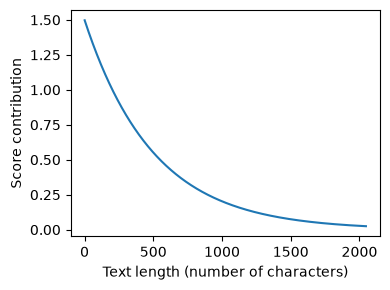

In [6]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)

    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    #plt.savefig("brevity_curve.pdf")
    plt.show()

plot_brevity_curve(500)

In [7]:
print(round(heuristic_score(response_1), 3))

2.073


In [9]:
print(round(heuristic_score(response_2), 3))

2.517


Token probability scores

In [13]:
@torch.inference_mode()
def calc_next_token_probas(model,tokenizer,prompt,device,show=True):
  token_ids = torch.tensor(tokenizer.encode(prompt),device=device)
  logits = model(token_ids.unsqueeze(0)).squeeze(0)
  all_probas = torch.softmax(logits,dim=-1)
  t_idx = torch.arange(0,token_ids.shape[0] -1,device=device)
  next_ids = token_ids[1:]
  next_token_probas = all_probas[t_idx,next_ids]
  prob_next_token_probas = torch.prod(next_token_probas)
  if show:
    print("Next Token Probabilities:",next_token_probas)
    print("Joint Probability:",prob_next_token_probas)
  else:
    return next_token_probas,prob_next_token_probas


In [14]:
torch.set_printoptions(precision=4, sci_mode=True)

In [15]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next Token Probabilities: tensor([5.7459e-05, 4.5312e-01, 1.6113e-02, 7.3828e-01, 1.8066e-01],
       dtype=torch.bfloat16)
Joint Probability: tensor(5.5879e-08, dtype=torch.bfloat16)


In [16]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Monteal"
    )

Next Token Probabilities: tensor([5.7459e-05, 4.5312e-01, 1.6113e-02, 7.3828e-01, 1.6950e-07, 4.1962e-05],
       dtype=torch.bfloat16)
Joint Probability: tensor(2.1955e-18, dtype=torch.bfloat16)


In [17]:
calc_next_token_probas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is hamburg"
    )

Next Token Probabilities: tensor([5.7459e-05, 4.5312e-01, 1.6113e-02, 7.3828e-01, 9.2983e-06],
       dtype=torch.bfloat16)
Joint Probability: tensor(2.8706e-12, dtype=torch.bfloat16)


scores to log-probabilities

In [18]:
@torch.inference_mode()
def calc_next_token_logprobas(model,tokenizer,prompt,device,show=True):
  token_ids = torch.tensor(tokenizer.encode(prompt),device=device)
  logits = model(token_ids.unsqueeze(0)).squeeze(0)
  all_logprobas = torch.log_softmax(logits,dim=-1)
  t_ix = torch.arange(0,token_ids.shape[0] -1 ,device=device)
  next_ids = token_ids[1:]
  next_token_logprobas = all_logprobas[t_ix,next_ids]
  sum_next_token_logprobas = torch.sum(next_token_logprobas)
  if show:
    print("Next Token Log Probabilities:",next_token_logprobas)
    print("Joint Log Probability:",sum_next_token_logprobas)
  else:
    return next_token_logprobas,sum_next_token_logprobas

In [19]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Berlin"
    )

Next Token Log Probabilities: tensor([-9.7500e+00, -7.9688e-01, -4.1250e+00, -3.0078e-01, -1.7109e+00],
       dtype=torch.bfloat16)
Joint Log Probability: tensor(-1.6625e+01, dtype=torch.bfloat16)


In [20]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Bridge"
    )

Next Token Log Probabilities: tensor([-9.7500e+00, -7.9688e-01, -4.1250e+00, -3.0078e-01, -1.5000e+01],
       dtype=torch.bfloat16)
Joint Log Probability: tensor(-3.0000e+01, dtype=torch.bfloat16)


In [21]:
calc_next_token_logprobas(
        model, tokenizer, device=device,
        prompt="The capital of Germany is Hamburg"
    )

Next Token Log Probabilities: tensor([-9.7500e+00, -7.9688e-01, -4.1250e+00, -3.0078e-01, -3.4688e+00],
       dtype=torch.bfloat16)
Joint Log Probability: tensor(-1.8500e+01, dtype=torch.bfloat16)


Scoring model confidence with log-probabilities

In [24]:
#Average logprob
@torch.inference_mode()
def avg_logprob_answer(model,tokenizer,prompt,answer,device='cpu'):
  prompts_ids = tokenizer.encode(prompt)
  answer_ids = tokenizer.encode(answer)
  full_ids = torch.tensor(prompts_ids + answer_ids,device=device)
  logits = model(full_ids.unsqueeze(0)).squeeze(0)
  logprobas = torch.log_softmax(logits,dim=-1)

  start = len(prompts_ids) -1
  end = full_ids.shape[0] -1

  t_idx = torch.arange(start,end,device=device)
  next_tokens = full_ids[start +1 : end+1]
  next_token_logps = logprobas[t_idx,next_tokens]
  return torch.mean(next_token_logps)

In [25]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Berlin.",
    device=device
)
print(score_1)

tensor(-2.1582e-01, dtype=torch.bfloat16)


In [26]:
score_2 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Germany?",
    answer=" The capital of Germany is Bridge.",
    device=device
)
print(score_2)

tensor(-3.8906e+00, dtype=torch.bfloat16)


Self-refinement through iterative feedback

In [30]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

torch.manual_seed(123)
initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 \boxed{18}

In [31]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical errors, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. Then propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )


critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 The question seems to have a typo. It should be "Half the value of $3x - 9$ is $x + 37$." Therefore, the value of $x$ is 18. The plan to fix issues would be: First, identify the typo in the question. Then, correct the typo by providing the correct equation. Finally, solve the equation to find the value of $x$.

In [32]:
def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )

refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 \boxed{18}

Explanation: The question is corrected to read "Half the value of $3x - 9$ is $x + 37$." The value of $x$ is 18, which satisfies the equation $18 = \frac{1}{2}(3 \cdot 18 - 9) = \frac{1}{2}(54 - 9) = \frac{1}{2}(45) = 22.5$. The revised answer is \boxed{18}.

In [38]:
def self_refinement_loop(model,tokenizer,raw_prompt,device,iterations=3,max_response_tokens=2048,max_critique_tokens=256,
                         score_fn=None,prompt_renderer=render_prompt,prompt_suffix='',verbose=False,temperature=0.7,top_p=0.9):
  steps=[]
  prompt = prompt_renderer(raw_prompt)+prompt_suffix
  current_full = generate_text_stream_concat_flex(model=model,tokenizer=tokenizer,prompt=prompt,device=device,max_new_tokens=max_response_tokens,
                                                  verbose=False,generate_func=generate_text_top_p_stream_cache,temperature=temperature,top_p=top_p)
  current_extracted = extract_final_candidate(current_full,fallback='number_then_full')
  if score_fn:
    current_score = score_fn(answer=current_full,prompt=prompt)
  else:
    current_score = 0.0
  for it in range(iterations):
    draft_before_full = current_full
    draft_before_extracted = current_extracted
    score_before = current_score
    critique_prompt = make_critique_prompt(raw_prompt,draft_before_full)
    critique_full = generate_text_stream_concat_flex(model=model,tokenizer=tokenizer,prompt=critique_prompt,device=device,max_new_tokens=max_response_tokens,
                                                  verbose=False,generate_func=generate_text_top_p_stream_cache,temperature=temperature,top_p=top_p)
    refine_prompt = make_refine_prompt(raw_prompt,draft_before_full,critique_full)
    revised_full = generate_text_stream_concat_flex(model=model,tokenizer=tokenizer,prompt=refine_prompt,device=device,max_new_tokens=max_response_tokens,
                                                  verbose=False,generate_func=generate_text_top_p_stream_cache,temperature=temperature,top_p=top_p)

    revised_extracted = extract_final_candidate(revised_full,fallback='number_then_full')
    if score_fn:
            revised_score = score_fn(
                answer=revised_full, prompt=prompt  # Still use original prompt here
            )
    else:
        revised_score = 0.0

    # Log the results
    step = {
        "iteration": it + 1,
        "draft_full": draft_before_full,
        "draft_extracted": draft_before_extracted,
        "critique": critique_full,
        "revised_full": revised_full,
        "revised_extracted": revised_extracted,
        "score_before": score_before,
        "score_after": revised_score,
    }
    steps.append(step)

    if verbose:
        print(
            f"[Refinement {it+1}/{iterations}]"
            f"\nCurrent: {draft_before_extracted}"
            f"\nRevised: {revised_extracted}"
            f"\nScore before: {score_before:.3f}"
            f"\nScore after: {revised_score:.3f}"
            f"\n{'=' * 25}"
        )

    # Accept revised response if it's not worse
    if revised_score >= current_score:
        current_full = revised_full
        current_extracted = revised_extracted
        current_score = revised_score

  return {
      "final_full": current_full,
      "final_extracted": current_extracted,
      "steps": steps,
  }

In [39]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)

In [40]:
torch.manual_seed(1)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 83
Revised: 83
Score before: -0.086
Score after: -1.648
[Refinement 2/2]
Current: 83
Revised: 83
Score before: -0.086
Score after: -1.500
